<a href="https://colab.research.google.com/github/Eduardo-42/STC/blob/main/STC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
#Importamos las librerias principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
#Cargamos dataset a utilizar
dfStc = pd.read_csv("/content/ProbDelMetro2021.csv")

In [33]:
#Visualizacion del dataframe
dfStc.head(5)

,NOMBRE,ALCALDIAS,Delitos_DEL,QTY_EST_DEL,DelitosXEstacion,Afluencia_total,prob_Delito_Usr,prob_Delito_MillonUsr
0,Balbuena,VENUSTIANO_CARRANZA,152,20,7.6,2246042,3.380000e-06,3.38
1,Balderas,CUAUHTEMOC,324,30,10.8,9646300,1.120000e-06,1.12
2,Boulevard Puerto Aereo,VENUSTIANO_CARRANZA,152,20,7.6,5468560,1.390000e-06,1.39
3,Candelaria,VENUSTIANO_CARRANZA,152,20,7.6,16739484,4.500000e-07,0.45
4,Cuauhtemoc,CUAUHTEMOC,324,30,10.8,4054718,2.660000e-06,2.66


In [34]:
dfStc.describe()

,Delitos_DEL,QTY_EST_DEL,DelitosXEstacion,Afluencia_total,prob_Delito_Usr,prob_Delito_MillonUsr
count,135.000000,135.000000,135.000000,1.350000e+02,1.350000e+02,135.000000
mean,122.696296,17.755556,5.928709,6.958610e+06,1.858296e-06,1.858296
std,113.446172,7.921694,3.620087,1.335297e+07,1.602946e-06,1.602946
min,6.000000,3.000000,1.200000,3.015940e+05,6.000000e-08,0.060000
25%,36.000000,13.000000,2.944400,2.158972e+06,6.650000e-07,0.665000
50%,74.000000,17.000000,4.352900,3.533270e+06,1.230000e-06,1.230000
75%,152.000000,20.000000,7.600000,6.974244e+06,2.830000e-06,2.830000
max,324.000000,30.000000,15.666700,1.379798e+08,8.030000e-06,8.030000


In [35]:
dfStc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NOMBRE                 135 non-null    object 
 1   ALCALDIAS              135 non-null    object 
 2   Delitos_DEL            135 non-null    int64  
 3   QTY_EST_DEL            135 non-null    int64  
 4   DelitosXEstacion       135 non-null    float64
 5   Afluencia_total        135 non-null    int64  
 6   prob_Delito_Usr        135 non-null    float64
 7   prob_Delito_MillonUsr  135 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 8.6+ KB


<Axes: xlabel='prob_Delito_MillonUsr', ylabel='ALCALDIAS'>

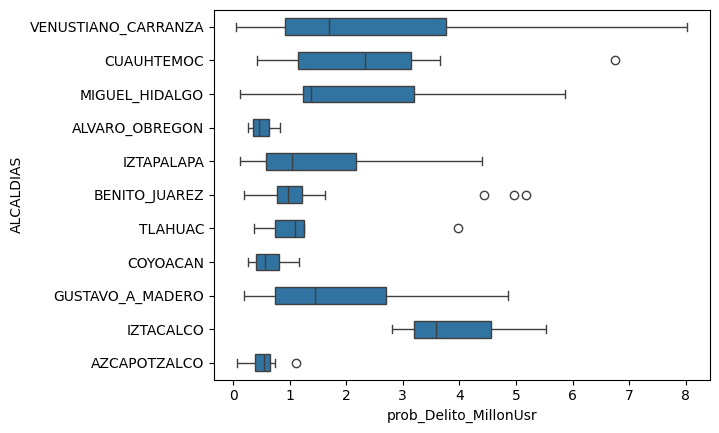

In [36]:
sns.boxplot(data=dfStc, x="prob_Delito_MillonUsr", y="ALCALDIAS", width=.5)

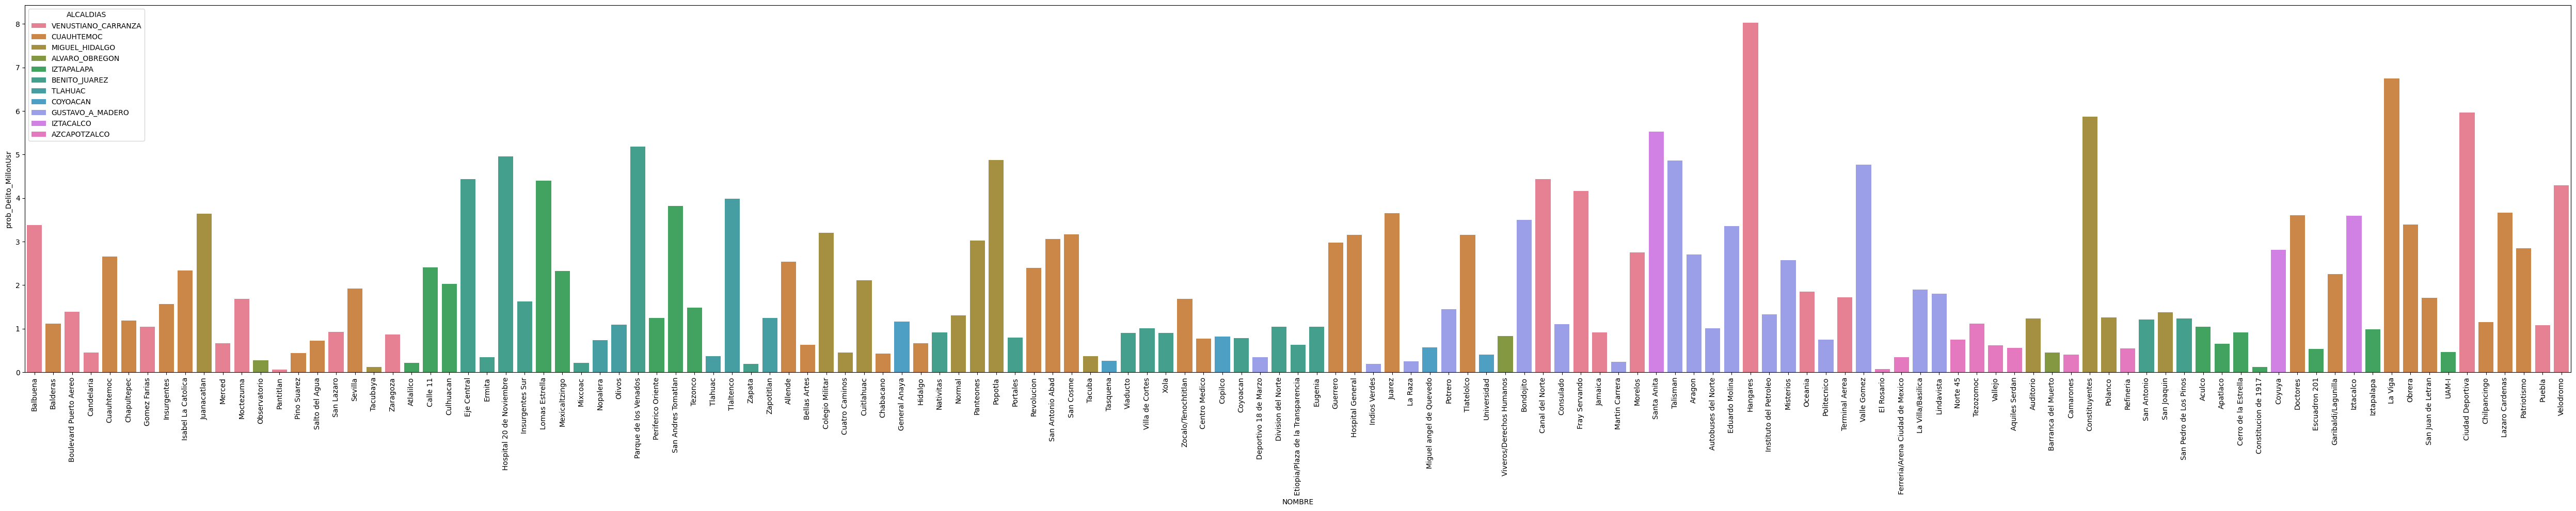

In [37]:
plt.figure(figsize=(50, 10))
sns.barplot(dfStc, x="NOMBRE", y="prob_Delito_MillonUsr", hue="ALCALDIAS")
plt.xticks(rotation='vertical')
plt.tight_layout()

In [38]:

def probAsalto(estaciones):

  prob = []
  for estacion in estacionesUsadas:
    probpermillonEstacion = dfStc.loc[dfStc['NOMBRE']==estacion, 'prob_Delito_MillonUsr'].iloc[0]
    probpermillonEstacion = probpermillonEstacion / 1000000
    probperEstacionDia = probpermillonEstacion / 365
    seguridadxEstacion = 1 - probperEstacionDia
    prob.append(seguridadxEstacion)


  prob = np.array(prob)
  probTotal = np.prod(prob)
  proasaltoXdia = 1 - probTotal
  proasaltoXdia = proasaltoXdia * 100

  return proasaltoXdia







In [39]:
estacionesUsadas = ['Cuauhtemoc', 'Chapultepec','Salto del Agua']
trayecto = probAsalto(estacionesUsadas)
str(trayecto)

'1.2520547931771375e-06'

In [40]:
!pip install googlemaps

In [41]:
API_KEY = ''

In [42]:
import googlemaps
from datetime import datetime

# 1. Inicializa el cliente con tu clave de API
# ¡¡Asegúrate de reemplazar 'TU_API_KEY'!!
gmaps = googlemaps.Client(key=API_KEY)

# 2. Define los puntos de origen y destino
# Usaremos lugares conocidos de la Ciudad de México
origen = "Estacion Metro Balbuena"
destino = "Estacion Metro Taxqueña"

print(f"Buscando ruta de '{origen}' a '{destino}'...")

# 3. Realiza la petición a la API de Direcciones
# - mode="transit" le pide que busque rutas en transporte público (metro, metrobús, etc.)
# - departure_time=now le ayuda a obtener rutas relevantes para el momento actual
try:
    now = datetime.now()
    directions_result = gmaps.directions(origen,
                                         destino,
                                         transit_mode="subway",
                                         mode = 'transit',
                                         departure_time=now)

    # 4. Procesa y muestra la respuesta
    if directions_result:
      #print(directions_result[0])
        # La API puede devolver varias rutas, tomamos la primera y más probable
      ruta = directions_result[0]

        #print("\n--- RESUMEN DE LA RUTA ---")
        # Imprime la distancia y duración total del viaje
        #print(f"Distancia total: {ruta['legs'][0]['distance']['text']}")
        #print(f"Duración estimada: {ruta['legs'][0]['duration']['text']}")
        #print(f"Ruta sugerida: {ruta['summary']}")

        #print("\n--- PASOS DETALLADOS ---")
        # Recorre cada paso de la ruta
        #for i, paso in enumerate(ruta['legs'][0]['steps']):
            # extrae la instrucción en HTML y la limpia un poco
        #    instruccion = paso['html_instructions']
        #    distancia = paso.get('distance', {}).get('text', '') # algunos pasos no tienen distancia
        #    duracion = paso.get('duration', {}).get('text', '')

        #    print(f"{i+1}. {instruccion} ({duracion} - {distancia})")

            # Si el paso es de transporte público, muestra los detalles
         #   if paso['travel_mode'] == 'TRANSIT':
         #       detalles_transito = paso['transit_details']

         #       print(f"   -> Línea: {detalles_transito['line']['name']}")
         #       print(f"   -> Salir en: {detalles_transito['arrival_stop']['name']}")
         #       print(f"   -> Número de paradas: {detalles_transito['num_stops']}")

    else:
        print("No se encontró una ruta.")

except googlemaps.exceptions.ApiError as e:
    print(f"Error al llamar a la API: {e}")

Buscando ruta de 'Estacion Metro Balbuena' a 'Estacion Metro Taxqueña'...


In [43]:
steps = ruta['legs'][0]['steps']


In [44]:
steps[0]['travel_mode']

'WALKING'

In [45]:
steps[1]

{'distance': {'text': '4.2 km', 'value': 4236},
 'duration': {'text': '8 mins', 'value': 490},
 'end_location': {'lat': 19.42592, 'lng': -99.13264},
 'html_instructions': 'Subway towards Observatorio',
 'polyline': {'points': 'sspuBt~z{QTLyOx_@aAxBQ`@gAbC[r@Wl@{C~GeCbHcAvBkAtAKNKJWRo@VsAFaADQ?oCNm@Le@VWj@Iz@Cv@Af@?hAA`BMrGOxCKnAKjACp@@n@DTHZLb@Z`@`@^r@`@^Nz@HrGDt@?b@?nLHb@?hB@\\Bd@Ht@X\\P`@b@Zh@LZRz@@@?B?jAAFOnBEd@u@hIm@~GAREd@_B~RC^Fz@bAbCDLBN?T?VUzFA?'},
 'start_location': {'lat': 19.42346, 'lng': -99.10266999999999},
 'transit_details': {'arrival_stop': {'location': {'lat': 19.42592,
    'lng': -99.13264},
   'name': 'Pino Suárez'},
  'arrival_time': {'text': '3:09\u202fPM',
   'time_zone': 'America/Mexico_City',
   'value': 1758143370},
  'departure_stop': {'location': {'lat': 19.42346, 'lng': -99.10266999999999},
   'name': 'Balbuena'},
  'departure_time': {'text': '3:01\u202fPM',
   'time_zone': 'America/Mexico_City',
   'value': 1758142880},
  'headsign': 'Observatorio',
  'head

In [46]:
for step in steps:
  travelMode = step['travel_mode']
  if travelMode == 'TRANSIT':
    lineSTC: step['transit_details']['line']['short_name']
    strartStation = step['transit_details']['departure_stop']['name']
    endStation = step['transit_details']['arrival_stop']['name']
    numberStops = step['transit_details']['num_stops']

  else:
    pass
  print(travelMode)

WALKING
TRANSIT
WALKING
TRANSIT
WALKING


In [47]:
steps[1]['transit_details']['num_stops']

5

In [48]:
dfStcStops = pd.read_csv("/content/AlcaldiasSTC.csv")

In [49]:
dfStcStops.head(5)

,SISTEMA,NOMBRE,LINEA,EST,CVE_EST,CVE_EOD17,TIPO,ALCALDIAS,AnO
0,STC Metro,Aculco,8,13,STC0813,5134,Intermedia,IZTAPALAPA,1994
1,STC Metro,Allende,2,12,STC0212,5041,Intermedia,CUAUHTEMOC,1970
2,STC Metro,Apatlaco,8,12,STC0812,5135,Intermedia,IZTAPALAPA,1994
3,STC Metro,Aquiles Serdan,7,2,STC0702,5120,Intermedia,AZCAPOTZALCO,1988
4,STC Metro,Aragon,5,9,STC0509,5096,Intermedia,GUSTAVO_A_MADERO,1981


In [64]:
dfStcStops['NOMBRE'].unique()

array(['Aculco', 'Allende', 'Apatlaco', 'Aquiles Serdan', 'Aragon',
       'Atlalilco', 'Auditorio', 'Autobuses del Norte', 'Balbuena',
       'Balderas', 'Barranca del Muerto', 'Bellas Artes', 'Bondojito',
       'Boulevard Puerto Aereo', 'Calle 11', 'Camarones',
       'Canal del Norte', 'Candelaria', 'Centro Medico',
       'Cerro de la Estrella', 'Ciudad Deportiva', 'Colegio Militar',
       'Constitucion de 1917', 'Constituyentes', 'Consulado', 'Copilco',
       'Coyoacan', 'Coyuya', 'Cuatro Caminos', 'Cuauhtemoc', 'Cuitlahuac',
       'Culhuacan', 'Chabacano', 'Chapultepec', 'Chilpancingo',
       'Deportivo 18 de Marzo', 'Division del Norte', 'Doctores',
       'Eduardo Molina', 'Eje Central', 'El Rosario', 'Ermita',
       'Escuadron 201', 'Etiopia/Plaza de la Transparencia', 'Eugenia',
       'Ferreria/Arena Ciudad de Mexico', 'Fray Servando',
       'Garibaldi/Lagunilla', 'General Anaya', 'Gomez Farias', 'Guerrero',
       'Hangares', 'Hidalgo', 'Hospital 20 de Noviembre',
  

In [75]:
def replaceVowels(stringWord):


  espChars = ['á', 'é', 'í', 'ó', 'ú']
  repchars = ['a','e','i','o','u']
  for char, repchar in zip(espChars,repchars):
    stringWord = stringWord.replace(char, repchar)
  return stringWord

In [59]:
dfSelecStops = dfStcStops.loc[(dfStcStops['LINEA']==1) & (dfStcStops['NOMBRE']=='Balbuena'), 'EST'].iloc[0]



In [62]:
dfSelecStops = dfStcStops.loc[(dfStcStops['LINEA']==1) & (dfStcStops['NOMBRE']=='Pino Suarez'), 'EST'].iloc[0]

In [63]:
dfSelecStops

np.int64(10)